# MBG Smart Plate: Sistem Personalisasi Menu Gizi Berbasis Web untuk Mendukung Program Makan Bergizi Gratis

## Permasalahan/Pertanyaan Bisnis

**Latar Belakang:**
Program Makan Bergizi Gratis (MBG) menghadapi tantangan dalam personalisasi gizi. Saat ini, sistem cenderung memberikan menu generik tanpa mempertimbangkan kondisi fisik unik setiap siswa (stunting, gizi normal, atau overweight). Solusi yang ditawarkan adalah sistem personalisasi menu otomatis berdasarkan klasifikasi kondisi fisik berdasarkan status gizi siswa.

- Pertanyaan 1 (Model Klasifikasi): Bagaimana performa model machine learning dalam mengklasifikasikan status gizi siswa (Underweight, Normal, Overweight) berdasarkan data antropometri (usia, jenis kelamin, tinggi badan, berat badan)? Algoritma mana yang memberikan akurasi tertinggi?

- Pertanyaan 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa? Apakah jenis kelamin berpengaruh signifikan terhadap distribusi status gizi?

- Pertanyaan 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang paling membutuhkan perhatian?

- Pertanyaan 4 (Rekomendasi Gizi): Berdasarkan data TKPI, bahan pangan apa saja yang memiliki kandungan energi, protein, dan karbohidrat tinggi untuk menaikkan berat badan (kategori Underweight)? Dan bahan apa yang rendah kalori tapi tinggi serat untuk kategori Overweight?

## Import Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

## Data Wrangling

### Gathering Data

In [3]:
# 1. Dataset Antropometri (BMI)
url_bmi = 'https://docs.google.com/spreadsheets/d/1ub4EZ50clYbgw_yi0HQX-2OD99cXmMa4-NxrgX3tn88/export?format=csv'
df_bmi = pd.read_csv(url_bmi)

print("\nDataset Antropometri")
print(f"Dataset memiliki {df_bmi.shape[0]} baris dan {df_bmi.shape[1]} kolom")
print("5 Baris Pertama:")
df_bmi.head()


Dataset Antropometri
Dataset memiliki 30000 baris dan 6 kolom
5 Baris Pertama:


,umur,jenis_kelamin,tinggi_cm,berat_kg,bmi,label
0,11,P,140.7,34.5,17.41,Normal
1,10,L,135.9,29.5,15.98,Normal
2,11,P,138.9,36.2,18.80,Gemuk
3,10,P,131.9,28.5,16.37,Normal
4,6,L,117.0,17.3,12.66,Kurus


In [4]:
# 2. Dataset TKPI
url_tkpi = 'https://docs.google.com/spreadsheets/d/1VcYK__gUuteds8Hk7OT9S_tEoLCyRqy3/export?format=csv'
df_tkpi = pd.read_csv(url_tkpi)

print("\nDataset TKPI")
print(f"Dataset memiliki {df_tkpi.shape[0]} baris dan {df_tkpi.shape[1]} kolom")
print("5 Baris Pertama:")
df_tkpi.head()


Dataset TKPI
Dataset memiliki 1179 baris dan 25 kolom
5 Baris Pertama:


,KODE,NAMA BAHAN,SUMBER,AIR (g),ENERGI (Kal),PROTEIN (g),LEMAK (g),KH (g),SERAT (g),ABU (g),...,TEMBAGA (mg),SENG (mg),RETINOL (mcg),B-KAR (mcg),KAR-TOTAL (mcg),THIAMIN (mg),RIBOFLAVIN (mg),NIASIN (mg),VIT-C (mg),BDD (%)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TUNGGAL/SINGLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AR001,"Beras giling, mentah",KZGMI-2001,12.0,357.0,8.4,1.7,77.1,0.2,0.8,...,0.10,0.5,0,0,0,0.20,0.08,2.6,0,100.0
4,AR002,"Beras giling var pelita, mentah",KZGPI- 1990,11.4,369.0,9.5,1.4,77.1,0.4,0.6,...,0.00,0.0,0,0,0,0.26,0.00,0.0,0,100.0


### Assessing Data

In [5]:
print("\nInformasi Dataset BMI:")
df_bmi.info()

print("\nMissing Values Dataset BMI:")
print(df_bmi.isnull().sum())

print("\nDuplikasi Dataset BMI:")
print(f"Jumlah duplikat: {df_bmi.duplicated().sum()}")

print("\nStatistik Deskriptif Kolom Numerik Dataset BMI:")
df_bmi.describe()

print("\nUnique Values Kolom Kategorikal Dataset BMI:")
print(f"Jenis Kelamin: {df_bmi['jenis_kelamin'].unique()}")
print(f"Label Status Gizi: {df_bmi['label'].unique()}")


Informasi Dataset BMI:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           30000 non-null  int64  
 1   jenis_kelamin  30000 non-null  str    
 2   tinggi_cm      30000 non-null  float64
 3   berat_kg       30000 non-null  float64
 4   bmi            30000 non-null  float64
 5   label          30000 non-null  str    
dtypes: float64(3), int64(1), str(2)
memory usage: 1.6 MB

Missing Values Dataset BMI:
umur             0
jenis_kelamin    0
tinggi_cm        0
berat_kg         0
bmi              0
label            0
dtype: int64

Duplikasi Dataset BMI:
Jumlah duplikat: 2078

Statistik Deskriptif Kolom Numerik Dataset BMI:

Unique Values Kolom Kategorikal Dataset BMI:
Jenis Kelamin: <ArrowStringArray>
['P', 'L']
Length: 2, dtype: str
Label Status Gizi: <ArrowStringArray>
['Normal', 'Gemuk', 'Kurus', 'Obesitas']
Length: 4, dtype: str


In [6]:
print("\nInformasi Dataset TKPI:")
df_tkpi.info()

print("\nMissing Values Dataset TKPI:")
print(df_tkpi.isnull().sum())


Informasi Dataset TKPI:
<class 'pandas.DataFrame'>
RangeIndex: 1179 entries, 0 to 1178
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   KODE             1177 non-null   str    
 1   NAMA BAHAN       1146 non-null   str    
 2   SUMBER           1146 non-null   str    
 3   AIR (g)          1146 non-null   float64
 4   ENERGI (Kal)     1146 non-null   float64
 5   PROTEIN (g)      1145 non-null   float64
 6   LEMAK (g)        1145 non-null   str    
 7   KH (g)           1146 non-null   float64
 8   SERAT (g)        967 non-null    str    
 9   ABU (g)          1146 non-null   str    
 10  KALSIUM (mg)     1129 non-null   str    
 11  FOSFOR (mg)      1128 non-null   str    
 12  BESI (mg)        1125 non-null   str    
 13  NATRIUM (mg)     916 non-null    str    
 14  KALIUM (mg)      879 non-null    str    
 15  TEMBAGA (mg)     854 non-null    str    
 16  SENG (mg)        859 non-null    str    
 17  

### Cleaning Data

In [7]:
print("\nTahap Cleaning Dataset BMI")

# Rename kolom
df_bmi = df_bmi.rename(columns={
    'umur': 'Age',
    'jenis_kelamin': 'Gender',
    'tinggi_cm': 'Height',
    'berat_kg': 'Weight',
    'bmi': 'BMI',
    'label': 'Status_Gizi'
})

# Konversi Gender ke numerik (0: Perempuan, 1: Laki-laki)
df_bmi['Gender_Encoded'] = df_bmi['Gender'].map({'Pria': 1, 'Wanita': 0})
    
# Ambil hanya 6 kolom yang diperlukan
kolom_yang_dipakai = ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Status_Gizi']
df_bmi = df_bmi[kolom_yang_dipakai]

print(f"\nCek Missing Values per kolom:")
print(df_bmi.isnull().sum())
print(f"\nTotal Missing Values: {df_bmi.isnull().sum().sum()}")

# Cek jumlah duplikat
print(f"\nTotal duplikat: {df_bmi.duplicated().sum()} baris")

if df_bmi.duplicated().sum() > 0:
    duplikat = df_bmi[df_bmi.duplicated(keep=False)].sort_values(list(df_bmi.columns))
    print(f"\n[2] Menampilkan {len(duplikat)} baris yang duplikat:")
    print(duplikat)
    
    # Hitung kelompok duplikat
    print(f"\n[3] Kelompok duplikat (nilai yang sama persis):")
    kelompok = df_bmi[df_bmi.duplicated(keep=False)].groupby(list(df_bmi.columns)).size().reset_index(name='jumlah')
    print(kelompok)
else:
    print("\n[2] Tidak ada baris duplikat!")

# Hapus duplikat
df_bmi = df_bmi.drop_duplicates(keep='first')
print(f"\n[4] Setelah hapus duplikat: {df_bmi.shape[0]} baris")

# Cek outlier pada Height dan Weight
Q1_h = df_bmi['Height'].quantile(0.25)
Q3_h = df_bmi['Height'].quantile(0.75)
IQR_h = Q3_h - Q1_h
lower_h = Q1_h - 1.5 * IQR_h
upper_h = Q3_h + 1.5 * IQR_h

Q1_w = df_bmi['Weight'].quantile(0.25)
Q3_w = df_bmi['Weight'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lower_w = Q1_w - 1.5 * IQR_w
upper_w = Q3_w + 1.5 * IQR_w

outliers_h = df_bmi[(df_bmi['Height'] < lower_h) | (df_bmi['Height'] > upper_h)]
outliers_w = df_bmi[(df_bmi['Weight'] < lower_w) | (df_bmi['Weight'] > upper_w)]

print(f"Outlier Tinggi Badan: {len(outliers_h)}")
print(f"Outlier Berat Badan: {len(outliers_w)}")

# Hapus outlier
df_bmi_clean = df_bmi[(df_bmi['Height'] >= lower_h) & (df_bmi['Height'] <= upper_h)]
df_bmi_clean = df_bmi_clean[(df_bmi_clean['Weight'] >= lower_w) & (df_bmi_clean['Weight'] <= upper_w)]

print(f"Ukuran data BMI awal: {df_bmi.shape}")
print(f"Ukuran data BMI setelah cleaning: {df_bmi_clean.shape}")


Tahap Cleaning Dataset BMI

Cek Missing Values per kolom:
Age            0
Gender         0
Height         0
Weight         0
BMI            0
Status_Gizi    0
dtype: int64

Total Missing Values: 0

Total duplikat: 2078 baris

[2] Menampilkan 3386 baris yang duplikat:
       Age Gender  Height  Weight    BMI Status_Gizi
953      6      L   110.0    17.0  14.05      Normal
6519     6      L   110.0    17.0  14.05      Normal
7663     6      L   110.0    17.0  14.05      Normal
8638     6      L   110.0    17.0  14.05      Normal
8877     6      L   110.0    17.0  14.05      Normal
...    ...    ...     ...     ...    ...         ...
27725   12      P   148.7    40.5  18.32       Gemuk
10261   12      P   148.7    41.5  18.79       Gemuk
10349   12      P   148.7    41.5  18.79       Gemuk
13148   12      P   149.0    40.4  18.21       Gemuk
14823   12      P   149.0    40.4  18.21       Gemuk

[3386 rows x 6 columns]

[3] Kelompok duplikat (nilai yang sama persis):
      Age Gender  He

In [24]:
print("\nTahap Cleaning Dataset TKPI")

# Pilih kolom yang relevan untuk rekomendasi menu
columns_needed = ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']
df_tkpi_clean = df_tkpi[columns_needed].copy()

# Hapus baris dengan missing values
df_tkpi_clean = df_tkpi_clean.dropna(subset=['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)'])

# Pembersihan simbol dalam kalimat 
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.replace('\n', ' ', regex=False)
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.replace('  ', ' ', regex=False)
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.strip()

# Konversi ke numeric
for col in ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']:
    df_tkpi_clean[col] = pd.to_numeric(df_tkpi_clean[col], errors='coerce')

# Hapus baris dengan nilai 0 atau NaN pada energi
df_tkpi_clean = df_tkpi_clean[df_tkpi_clean['ENERGI (Kal)'] > 0]

print(f"Ukuran data TKPI setelah tahap cleaning: {df_tkpi_clean.shape}")
print("5 Baris Pertama Dataset TKPI (Clean):")
df_tkpi_clean.head()

# Eliminasi Konten Haram
print(f"\nSebelum cleaning: {len(df_tkpi)} baris")
jumlah_sebelum = len(df_tkpi)
df_tkpi = df_tkpi[
    ~df_tkpi['NAMA BAHAN'].str.contains('babi|hiu|ikan hitam|Ayam goreng church', case=False, na=False)
].copy()

print(f"Setelah cleaning : {len(df_tkpi)} baris")


Tahap Cleaning Dataset TKPI
Ukuran data TKPI setelah tahap cleaning: (954, 6)
5 Baris Pertama Dataset TKPI (Clean):

Sebelum cleaning: 1165 baris
Setelah cleaning : 1163 baris


## Exploratory Data Analysis (EDA)

### 1. Distribusi Status Gizi 


Distribusi Status Gizi Siswa:
  Normal: 16947 siswa (60.7%)
  Gemuk: 8263 siswa (29.6%)
  Kurus: 2621 siswa (9.4%)
  Obesitas: 91 siswa (0.3%)


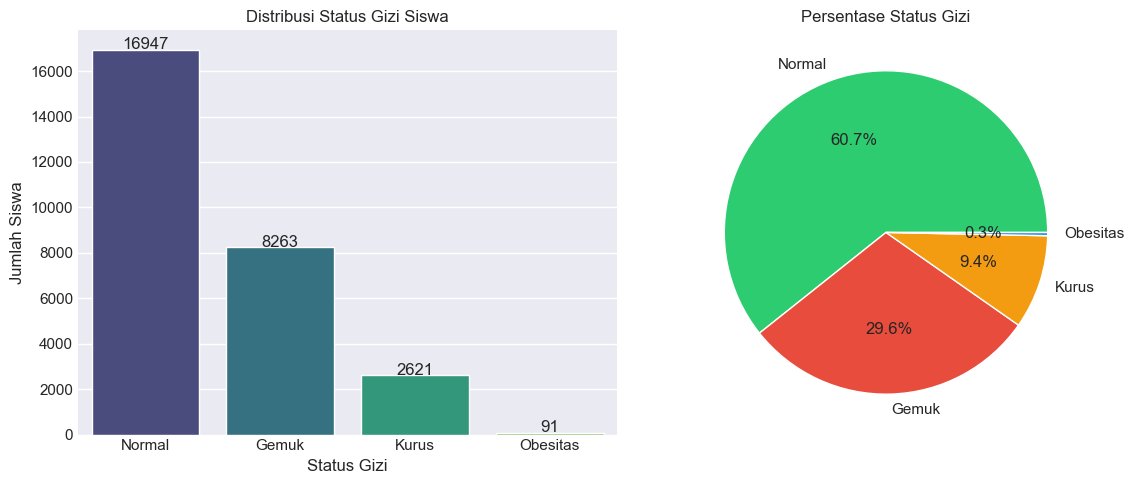

In [11]:
status_counts = df_bmi_clean['Status_Gizi'].value_counts()
status_pct = df_bmi_clean['Status_Gizi'].value_counts(normalize=True) * 100

print("\nDistribusi Status Gizi Siswa:")
for status, count in status_counts.items():
    pct = status_pct[status]
    print(f"  {status}: {count} siswa ({pct:.1f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Status Gizi Siswa')
axes[0].set_xlabel('Status Gizi')
axes[0].set_ylabel('Jumlah Siswa')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
axes[1].set_title('Persentase Status Gizi')

plt.tight_layout()
plt.show()

### 2. Analisis Berdasarkan Kelompok Usia dan Jenis Kelamin 


Distribusi Status Gizi per Kelompok Usia (%):
Status_Gizi  Gemuk  Kurus  Normal  Obesitas
Age_Group                                  
5-7 tahun      1.0   28.5    70.5       0.0
8-10 tahun    18.9   13.3    67.7       0.1
11-13 tahun   47.1    0.8    51.5       0.6

Distribusi Status Gizi per Jenis Kelamin (%):
Status_Gizi  Gemuk  Kurus  Normal  Obesitas
Gender                                     
L             29.1    9.1    61.4       0.3
P             30.1    9.6    60.0       0.3


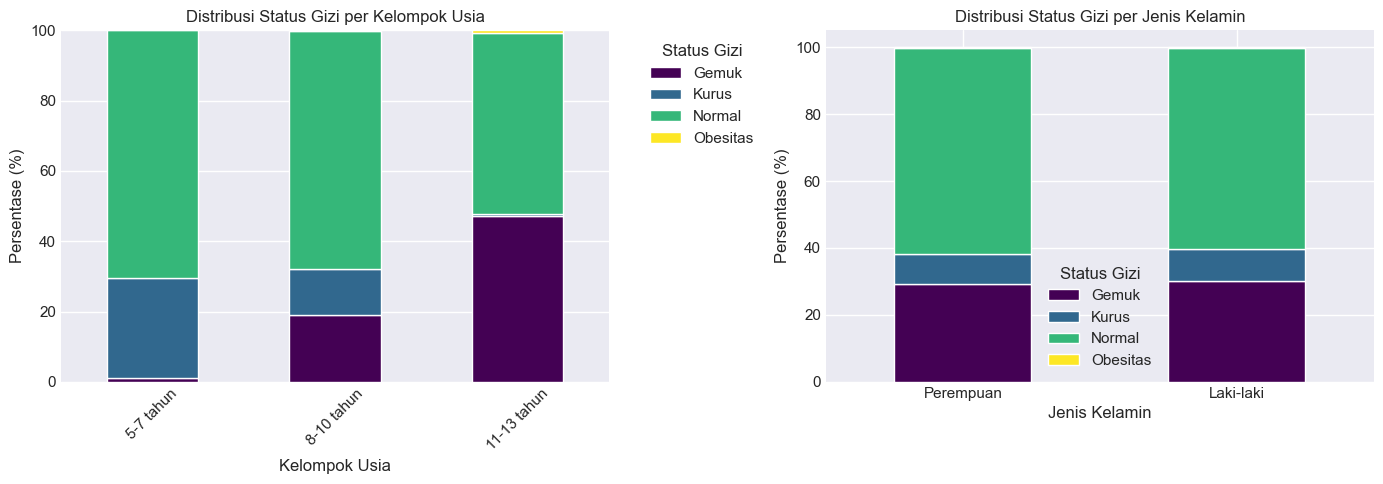

In [12]:
bins = [5, 7, 10, 13, 16]
labels = ['5-7 tahun', '8-10 tahun', '11-13 tahun', '14-16 tahun']
df_bmi_clean['Age_Group'] = pd.cut(df_bmi_clean['Age'], bins=bins, labels=labels, right=False)

# Crosstab usia vs status gizi
age_status = pd.crosstab(df_bmi_clean['Age_Group'], df_bmi_clean['Status_Gizi'], normalize='index') * 100
print("\nDistribusi Status Gizi per Kelompok Usia (%):")
print(age_status.round(1))

# Crosstab gender vs status gizi
gender_status = pd.crosstab(df_bmi_clean['Gender'], df_bmi_clean['Status_Gizi'], normalize='index') * 100
print("\nDistribusi Status Gizi per Jenis Kelamin (%):")
print(gender_status.round(1))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group analysis
age_status.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Distribusi Status Gizi per Kelompok Usia')
axes[0].set_xlabel('Kelompok Usia')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend(title='Status Gizi', bbox_to_anchor=(1.05, 1))
axes[0].tick_params(axis='x', rotation=45)

# Gender analysis
gender_status.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Distribusi Status Gizi per Jenis Kelamin')
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(title='Status Gizi')
axes[1].set_xticklabels(['Perempuan', 'Laki-laki'], rotation=0)

plt.tight_layout()
plt.show()

### 3. Analisis BMI per Status Gizi

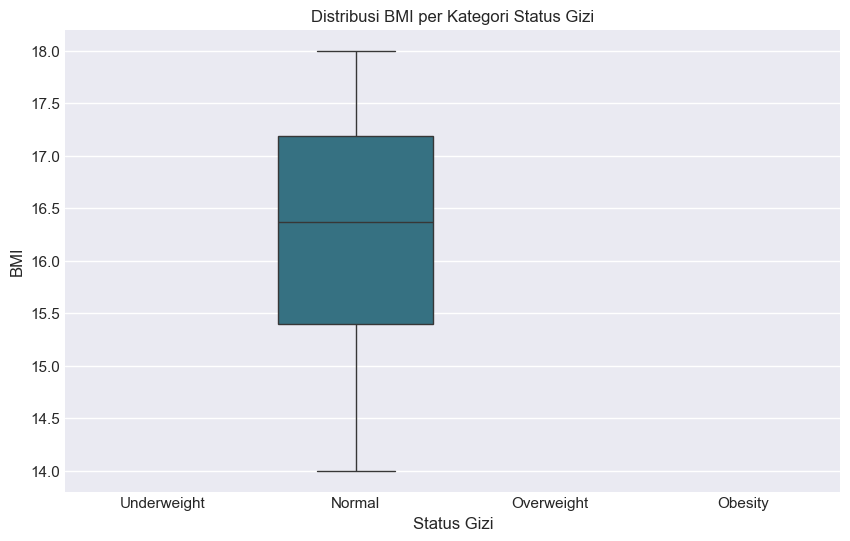


Statistik BMI per Status Gizi:
              mean   std    min    max
Status_Gizi                           
Gemuk        19.20  0.90  18.00  22.00
Kurus        13.33  0.48  11.90  14.00
Normal       16.26  1.09  14.00  18.00
Obesitas     22.41  0.37  22.01  23.88


In [13]:
# Boxplot BMI berdasarkan status gizi
plt.figure(figsize=(10, 6))
order = ['Underweight', 'Normal', 'Overweight', 'Obesity']
sns.boxplot(data=df_bmi_clean, x='Status_Gizi', y='BMI', order=order, palette='viridis')
plt.title('Distribusi BMI per Kategori Status Gizi')
plt.xlabel('Status Gizi')
plt.ylabel('BMI')
plt.show()

# Statistik BMI per status
print("\nStatistik BMI per Status Gizi:")
bmi_stats = df_bmi_clean.groupby('Status_Gizi')['BMI'].agg(['mean', 'std', 'min', 'max'])
print(bmi_stats.round(2))

### 4. Analisis Bahan Pangan dari TKPI


Kategori 1: Underweight

10 Bahan dengan Energi Tertinggi:
               NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  LEMAK (g)  KH (g)
              Minyak ikan         902.0          0.0      100.0     0.0
      Minyak kacang tanah         902.0          0.0      100.0     0.0
      Minyak kelapa sawit         884.0          0.0      100.0     0.0
            Minyak zaitun         884.0          0.0      100.0     0.0
           Minyak kedelai         883.0          0.0       99.9     0.0
             Minyak wijen         881.0          0.2       99.7     0.0
            Minyak kelapa         870.0          1.0       98.0     0.0
Lemak kerbau (lemak sapi)         818.0          1.5       90.0     0.0
                  Mentega         742.0          0.5       81.6     1.4
                 Margarin         720.0          0.6       81.0     0.4

10 Bahan dengan Protein Tertinggi:
                      NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  LEMAK (g)  KH (g)
Dendeng mujahir, goreng, masakan 

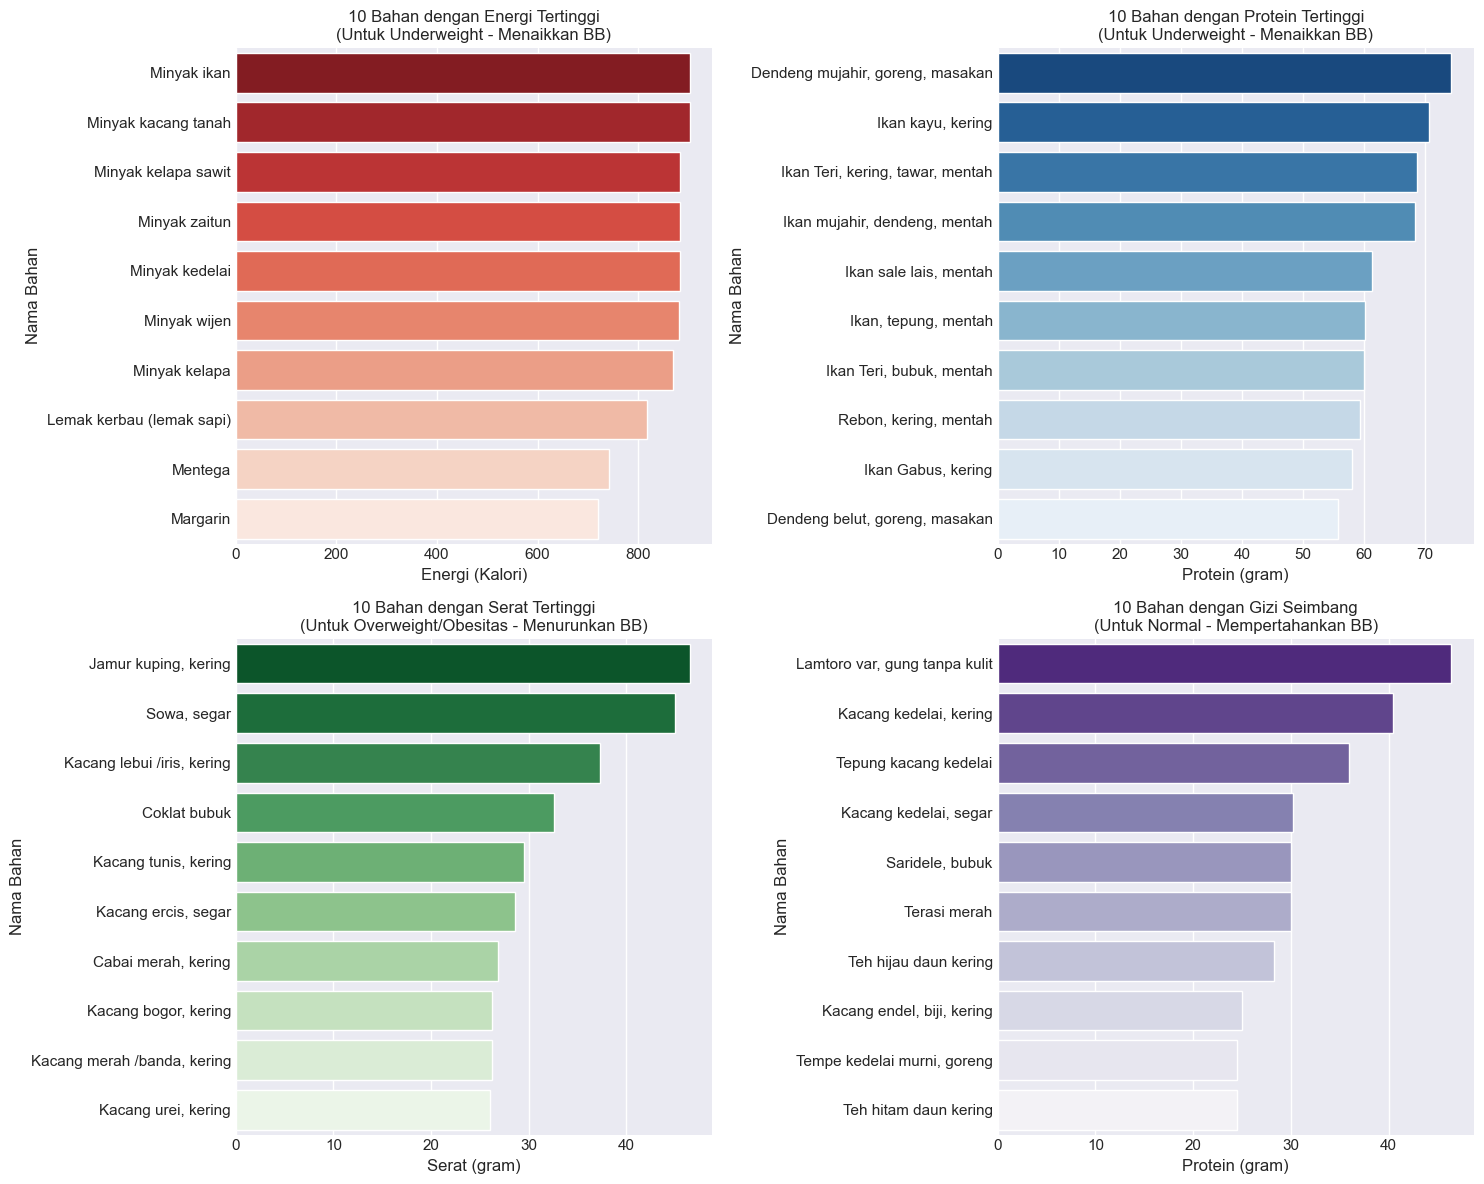

In [14]:
# Kategori 1: Underweight (Membutuhkan Kalori dan Protein Tinggi)
print("\nKategori 1: Underweight")
top_energy = df_tkpi_clean.nlargest(10, 'ENERGI (Kal)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)']]
top_protein = df_tkpi_clean.nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)']]

print("\n10 Bahan dengan Energi Tertinggi:")
print(top_energy.to_string(index=False))

print("\n10 Bahan dengan Protein Tertinggi:")
print(top_protein.to_string(index=False))


# Kategori 2: Overweight (Membutuhkan Serat dan Protein Rendah Lemak)
print("\nKategori 2: Overweight")
top_fiber = df_tkpi_clean.nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'LEMAK (g)']]
low_fat_protein = df_tkpi_clean[(df_tkpi_clean['LEMAK (g)'] < 10) & (df_tkpi_clean['PROTEIN (g)'] > 10)].nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'PROTEIN (g)', 'LEMAK (g)', 'ENERGI (Kal)']]

print("\n10 Bahan dengan Serat Tertinggi:")
print(top_fiber.to_string(index=False))

print("\n10 Bahan Protein Tinggi & Rendah Lemak (<10g lemak):")
print(low_fat_protein.to_string(index=False))


# Kategori 3: Normal (Menu Seimbang - Kombinasi Lengkap)
print("\nKategori 3: Normal")
# Bahan dengan gizi seimbang (protein cukup, energi sedang, serat cukup)
seimbang = df_tkpi_clean[
    (df_tkpi_clean['PROTEIN (g)'] > 5) & 
    (df_tkpi_clean['ENERGI (Kal)'] > 50) & 
    (df_tkpi_clean['ENERGI (Kal)'] < 400) &
    (df_tkpi_clean['SERAT (g)'] > 2)
].nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'PROTEIN (g)', 'ENERGI (Kal)', 'SERAT (g)', 'LEMAK (g)']]

print("\n10 Bahan dengan Gizi Seimbang (Protein cukup, Energi sedang, Ada Serat):")
print(seimbang.to_string(index=False))


# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Top 10 Energi Tertinggi (Underweight)
sns.barplot(data=top_energy, x='ENERGI (Kal)', y='NAMA BAHAN', ax=axes[0,0], palette='Reds_r')
axes[0,0].set_title('10 Bahan dengan Energi Tertinggi\n(Untuk Underweight - Menaikkan BB)', fontsize=12)
axes[0,0].set_xlabel('Energi (Kalori)')
axes[0,0].set_ylabel('Nama Bahan')

# Plot 2: Top 10 Protein Tertinggi (Underweight)
sns.barplot(data=top_protein, x='PROTEIN (g)', y='NAMA BAHAN', ax=axes[0,1], palette='Blues_r')
axes[0,1].set_title('10 Bahan dengan Protein Tertinggi\n(Untuk Underweight - Menaikkan BB)', fontsize=12)
axes[0,1].set_xlabel('Protein (gram)')
axes[0,1].set_ylabel('Nama Bahan')

# Plot 3: Top 10 Serat Tertinggi (Overweight/Obesitas)
sns.barplot(data=top_fiber, x='SERAT (g)', y='NAMA BAHAN', ax=axes[1,0], palette='Greens_r')
axes[1,0].set_title('10 Bahan dengan Serat Tertinggi\n(Untuk Overweight/Obesitas - Menurunkan BB)', fontsize=12)
axes[1,0].set_xlabel('Serat (gram)')
axes[1,0].set_ylabel('Nama Bahan')

# Plot 4: Top 10 Bahan Seimbang (Normal)
sns.barplot(data=seimbang, x='PROTEIN (g)', y='NAMA BAHAN', ax=axes[1,1], palette='Purples_r')
axes[1,1].set_title('10 Bahan dengan Gizi Seimbang\n(Untuk Normal - Mempertahankan BB)', fontsize=12)
axes[1,1].set_xlabel('Protein (gram)')
axes[1,1].set_ylabel('Nama Bahan')

plt.tight_layout()
plt.show()

**Insight:**
- 


## Membangun Model Klasifikasi

### 1. Persiapan Data untuk Model

In [15]:
if 'Gender_Encoded' not in df_bmi_clean.columns:
    df_bmi_clean['Gender_Encoded'] = df_bmi_clean['Gender'].map({'Pria': 1, 'Wanita': 0})

print(f"\nKolom yang tersedia: {df_bmi_clean.columns.tolist()}")

print("\nNilai unik di kolom Gender:")
print(df_bmi_clean['Gender'].unique())

print("\nNilai unik di kolom Gender_Encoded:")
print(df_bmi_clean['Gender_Encoded'].unique())

unique_gender = df_bmi_clean['Gender'].unique()
print(f"\nNilai Gender yang ditemukan: {unique_gender}")

gender_map = {}
for g in unique_gender:
    if g in ['Pria', 'Laki-laki', 'Male', 'L', '1']:
        gender_map[g] = 1
    elif g in ['Wanita', 'Perempuan', 'Female', 'P', '0']:
        gender_map[g] = 0
    else:
        gender_map[g] = -1  # tanda tidak dikenal

print(f"    Mapping: {gender_map}")

df_bmi_clean['Gender_Encoded'] = df_bmi_clean['Gender'].map(gender_map)

print(f"\n[4] Setelah mapping ulang:")
print(f"    Nilai unik Gender_Encoded: {df_bmi_clean['Gender_Encoded'].unique()}")
print(f"    Missing values: {df_bmi_clean['Gender_Encoded'].isnull().sum()}")

df_bmi_clean = df_bmi_clean[df_bmi_clean['Gender_Encoded'] != -1]
df_bmi_clean = df_bmi_clean.dropna(subset=['Gender_Encoded'])

print(f"\n[5] Shape akhir df_bmi_clean: {df_bmi_clean.shape}")


Kolom yang tersedia: ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Status_Gizi', 'Age_Group', 'Gender_Encoded']

Nilai unik di kolom Gender:
<ArrowStringArray>
['P', 'L']
Length: 2, dtype: str

Nilai unik di kolom Gender_Encoded:
[nan]

Nilai Gender yang ditemukan: <ArrowStringArray>
['P', 'L']
Length: 2, dtype: str
    Mapping: {'P': 0, 'L': 1}

[4] Setelah mapping ulang:
    Nilai unik Gender_Encoded: [0 1]
    Missing values: 0

[5] Shape akhir df_bmi_clean: (27922, 8)


In [16]:
print("\n[2] Nilai unik di kolom Gender_Encoded:")
print(df_bmi_clean['Gender_Encoded'].unique())

features = ['Age', 'Height', 'Weight', 'Gender_Encoded']
X = df_bmi_clean[features]
y = df_bmi_clean['Status_Gizi']

# Encoding target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping Status Gizi:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Train: {X_train.shape[0]} samples")
print(f"Data Test: {X_test.shape[0]} samples")
print(f"Jumlah kelas: {len(le.classes_)}")


[2] Nilai unik di kolom Gender_Encoded:
[0 1]
Mapping Status Gizi: {'Gemuk': np.int64(0), 'Kurus': np.int64(1), 'Normal': np.int64(2), 'Obesitas': np.int64(3)}
Data Train: 22337 samples
Data Test: 5585 samples
Jumlah kelas: 4


### 2. Membangun dan Evaluasi Model


Decision Tree
  Accuracy: 0.9893
  Precision: 0.9893
  Recall: 0.9893
  F1-Score: 0.9893

Random Forest
  Accuracy: 0.9882
  Precision: 0.9882
  Recall: 0.9882
  F1-Score: 0.9882

Gradient Boosting
  Accuracy: 0.9787
  Precision: 0.9786
  Recall: 0.9787
  F1-Score: 0.9786

SVM
  Accuracy: 0.9833
  Precision: 0.9834
  Recall: 0.9833
  F1-Score: 0.9820


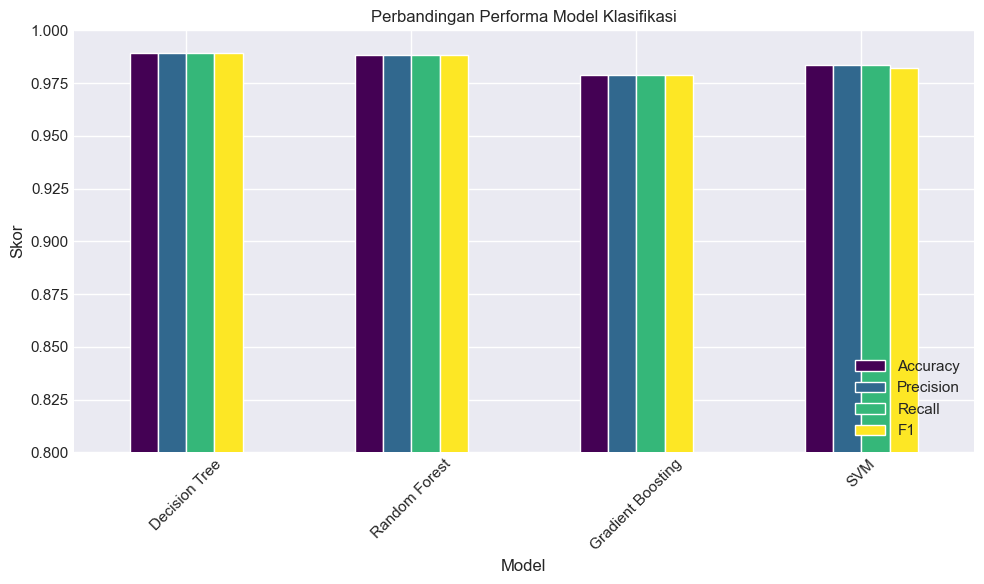

In [17]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

# Training dan evaluasi
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}
    
    print(f"\n{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Visualisasi perbandingan
results_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Perbandingan Performa Model Klasifikasi')
ax.set_xlabel('Model')
ax.set_ylabel('Skor')
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3. Feature Importance


Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6592 (65.9%)
  2. Tinggi Badan: 0.2683 (26.8%)
  3. Usia: 0.0696 (7.0%)
  4. Jenis Kelamin: 0.0029 (0.3%)


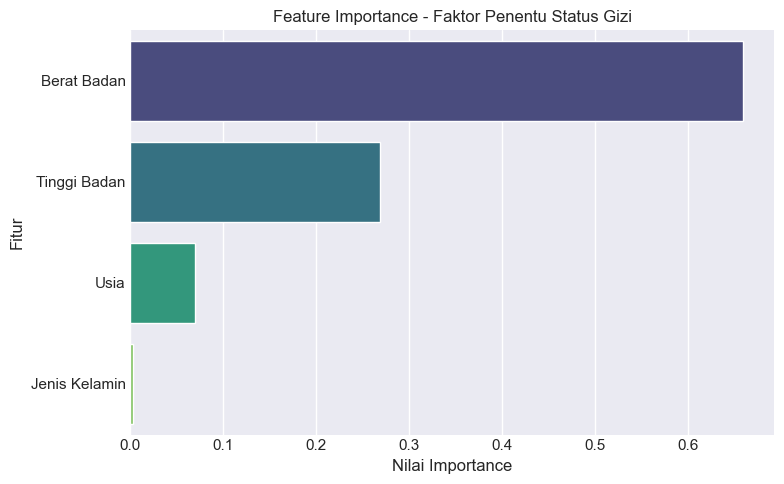

In [18]:
# Model terbaik untuk feature importance
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

importances = best_model.feature_importances_
feature_names = ['Usia', 'Tinggi Badan', 'Berat Badan', 'Jenis Kelamin']

indices = np.argsort(importances)[::-1]

print("\nFeature Importance (pengaruh terhadap status gizi):")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance - Faktor Penentu Status Gizi')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

### 4. Confusion Matrix Model Terbaik

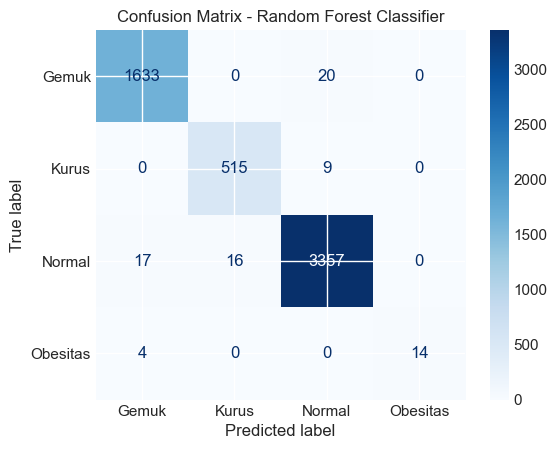


Classification Report:
              precision    recall  f1-score   support

       Gemuk       0.99      0.99      0.99      1653
       Kurus       0.97      0.98      0.98       524
      Normal       0.99      0.99      0.99      3390
    Obesitas       1.00      0.78      0.88        18

    accuracy                           0.99      5585
   macro avg       0.99      0.93      0.96      5585
weighted avg       0.99      0.99      0.99      5585



In [19]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

### 5. Hyperparameter Tuning

In [20]:
# Parameter grid untuk GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluasi model tuned
y_pred_tuned = grid_search.predict(X_test_scaled)
print(f"Test Accuracy (Tuned): {accuracy_score(y_test, y_pred_tuned):.4f}")

# Simpan model terbaik
joblib.dump(grid_search.best_estimator_, 'best_model_classification.h5')
print("\nModel terbaik disimpan sebagai 'best_model_classification.h5'")

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.9878
Test Accuracy (Tuned): 0.9884

Model terbaik disimpan sebagai 'best_model_classification.h5'


**Insight:**
- 

## Rekomendasi Menu Berbasis Bahan Mentah

In [25]:
# Fungsi rekomendasi sederhana
def rekomendasi_kategori(kategori):
    if kategori == 'Underweight':
        # Bahan dengan energi dan protein tinggi
        rekomendasi = df_tkpi_clean.nlargest(8, 'ENERGI (Kal)')
        target_nutrisi = "Meningkatkan berat badan"
        saran = "Tingkatkan asupan kalori dan protein"
    elif kategori in ['Overweight', 'Obesity']:
        # Bahan dengan serat tinggi, kalori sedang
        rekomendasi = df_tkpi_clean.nlargest(8, 'SERAT (g)')
        target_nutrisi = "Mengontrol/Menurunkan berat badan"
        saran = "Kurangi kalori, perbanyak serat, dan protein tanpa lemak"
    else:  # Normal
        rekomendasi = df_tkpi_clean.sample(8)
        target_nutrisi = "Mempertahankan berat badan ideal"
        saran = "Pola makan seimbang sesuai AKG"
    
    return rekomendasi, target_nutrisi, saran

# Contoh rekomendasi untuk setiap kategori
for kategori in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    rekomendasi, target, saran = rekomendasi_kategori(kategori)
    print(f"\n{'='*50}")
    print(f"KATEGORI: {kategori}")
    print(f"Target: {target}")
    print(f"Strategi: {saran}")
    print(f"\nRekomendasi Bahan Makanan:")
    print(rekomendasi[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'SERAT (g)']].to_string(index=False))


KATEGORI: Underweight
Target: Meningkatkan berat badan
Strategi: Tingkatkan asupan kalori dan protein

Rekomendasi Bahan Makanan:
               NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  SERAT (g)
              Minyak ikan         902.0          0.0        0.0
      Minyak kacang tanah         902.0          0.0        0.0
      Minyak kelapa sawit         884.0          0.0        0.0
            Minyak zaitun         884.0          0.0        0.0
           Minyak kedelai         883.0          0.0        0.0
             Minyak wijen         881.0          0.2        0.0
            Minyak kelapa         870.0          1.0        0.0
Lemak kerbau (lemak sapi)         818.0          1.5        0.0

KATEGORI: Normal
Target: Mempertahankan berat badan ideal
Strategi: Pola makan seimbang sesuai AKG

Rekomendasi Bahan Makanan:
          NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  SERAT (g)
      Mie aceh rebus         113.0          3.0        NaN
          Cangkuning         204.0          2.8

## Kesimpulan

- **Kesimpulan pertanyaan 1:**
B

- **Kesimpulan pertanyaan 2:**
B

- **Kesimpulan pertanyaan 3:**
B

- **Kesimpulan pertanyaan 4:**
B

## Lainnya

In [42]:
import subprocess
import sys
from importlib.metadata import version, PackageNotFoundError

def generate_requirements():
    libraries = [
        'numpy',
        'pandas',
        'matplotlib',
        'seaborn',
        'scipy',
        'scikit-learn',
        'joblib',
        'streamlit'
    ]
    
    print("="*60)
    print("GENERATE REQUIREMENTS.TXT")
    print("="*60)
    
    requirements = []
    
    for lib in libraries:
        try:
            # Cek versi library yang terinstall
            ver = version(lib)
            requirements.append(f"{lib}=={ver}")
            print(f"{lib}=={ver}")
        except PackageNotFoundError:
            print(f"{lib} tidak terinstall")
    
    # Tulis ke file requirements.txt
    with open('requirements.txt', 'w') as f:
        f.write('\n'.join(requirements))
    
    print("\n" + "="*60)
    print(f"✅ requirements.txt berhasil dibuat!")
    print(f"   Total {len(requirements)} library")
    print("="*60)
    
    print("\n📄 Isi requirements.txt:")
    print("-" * 40)
    with open('requirements.txt', 'r') as f:
        print(f.read())

if __name__ == "__main__":
    generate_requirements()

GENERATE REQUIREMENTS.TXT
numpy==2.4.4
pandas==3.0.2
matplotlib==3.10.9
seaborn==0.13.2
scipy==1.17.1
scikit-learn==1.8.0
joblib==1.5.3
streamlit==1.57.0

✅ requirements.txt berhasil dibuat!
   Total 8 library

📄 Isi requirements.txt:
----------------------------------------
numpy==2.4.4
pandas==3.0.2
matplotlib==3.10.9
seaborn==0.13.2
scipy==1.17.1
scikit-learn==1.8.0
joblib==1.5.3
streamlit==1.57.0
